In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#importing the boston house price prediction dataset
from sklearn.datasets import load_boston
#importing train_test_split to split the dataset into train and test set
from sklearn.model_selection import train_test_split

In [5]:
#storing the dataset in a variable
dataset = load_boston()

In [6]:
#store the dataset as a pandas dataframe
df = pd.DataFrame(data = dataset.data, columns = dataset.feature_names)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [7]:
df["MEDV"] = dataset.target
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [8]:
X = pd.concat((df["LSTAT"], df["RM"]), axis = 1)
X.head()

,LSTAT,RM
0,4.98,6.575
1,9.14,6.421
2,4.03,7.185
3,2.94,6.998
4,5.33,7.147


In [9]:
y = pd.DataFrame(df["MEDV"])
y.tail()

,MEDV
501,22.4
502,20.6
503,23.9
504,22.0
505,11.9


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [11]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(404, 2) (404, 1)
(102, 2) (102, 1)


In [12]:
X_train

,LSTAT,RM
196,4.08,7.287
302,8.67,6.495
344,4.61,6.874
189,5.39,7.185
413,20.08,5.155
...,...,...
267,7.44,8.297
93,6.21,6.211
119,13.61,5.731
40,1.98,7.024


In [68]:
#now we have the train and test set
#we have to find the optimal values for w and b that minimizes the cost fuction
#using gradient descent we will try to find those values
def update_w_and_b(x, y, w, b, alpha, moment1, moment2, beta):
    """this function updates the model parameters w and b,
    function arguments are x(input feature), y(output or the target), w, b, learning rate alpha
    """
    dl_dw = 0
    dl_db = 0
    N = len(x)
    m1, m2 = moment1, moment2
    for i in range(N):
        dl_dw += -2*x[i]*(y[i] - ((w+(beta*m1))*x[i] +b))
        dl_db += -2*(y[i] - (w*x[i] + (b+(beta*m2))))
    m1 = beta*m1 - alpha*(1/float(N))*dl_dw
    m2 = beta*m2 - alpha*(1/float(N))*dl_db
    w = w+m1
    b = b+m2
    return w, b, m1, m2

In [69]:
from matplotlib.pyplot import figure
def train(x, y, w, b, alpha, epochs):
    """this function searches for the best value for the parameters w and b,
    it takes x, y, w and b where w and b both are initially 0,
    the function loops the training set 
    """
    avg_loss_list = []
    w_list = []
    b_list = []
    img_list = []
    pred_val_at_diff_epoch = []
    moment1, moment2 = 0, 0
    beta = 0.9
    for num_of_epochs in range(epochs):
        xy = pd.concat([x, y], axis = 1)
        indexes = xy.index
        rand_indexes = np.random.choice(indexes, 15)
        xtrain = []
        ytrain = []
        for i in rand_indexes:
            xtrain.append(x[i])
            ytrain.append(y[i])
        w, b, moment1, moment2 = update_w_and_b(xtrain, ytrain, w, b, alpha, moment1, moment2, beta)
        if num_of_epochs%10 == 0:
            avg_loss_val = avg_loss(x, y, w, b)
            w_list.append(w)
            b_list.append(b)
            avg_loss_list.append(avg_loss_val)
        if num_of_epochs%500 == 0:
            avg_loss_val = avg_loss(x, y, w, b)
            print("epoch: ", num_of_epochs,"average loss: ",avg_loss_val)
            figure(figsize = (15, 10))
            plt.title(f"Epoch: {num_of_epochs}")
            plt.xlabel("X")
            plt.ylabel("y")
            plt.xlim(0, 9)
            plt.ylim(0, 50)
            
            plt.scatter(x, y)
            xt = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
            yt = []
            for i in xt:
                yt.append(predict(i, w, b))
                
            plt.plot(xt, yt, color = "red")
            
            plt.savefig(f"{num_of_epochs}.png")
            img_list.append(f"{num_of_epochs}.png")
            
            plt.show()
            
            pred_val_at_diff_epoch.append(predict(x[0], w, b))
    return w_list,b_list, avg_loss_list, w, b, img_list, pred_val_at_diff_epoch

In [71]:
def avg_loss(x, y, w, b):
    N = len(x)
    total_error = 0
    for i in range(N):
        total_error += (y[i] - (w*x[i]+b))**2
    return total_error/float(N)

In [72]:
def predict(x, w, b):
    return w*x+b

epoch:  0 average loss:  563.3101478101964


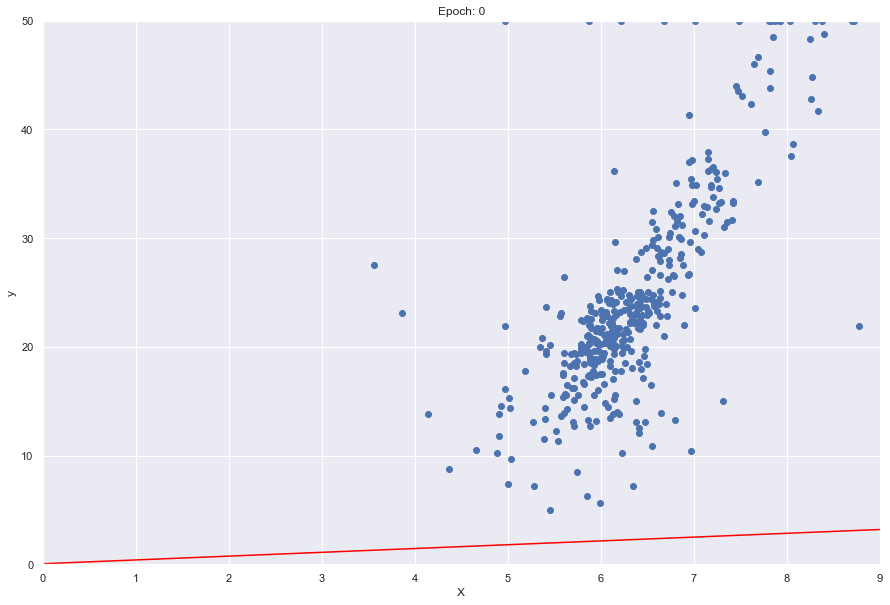

epoch:  500 average loss:  51.701480072723726


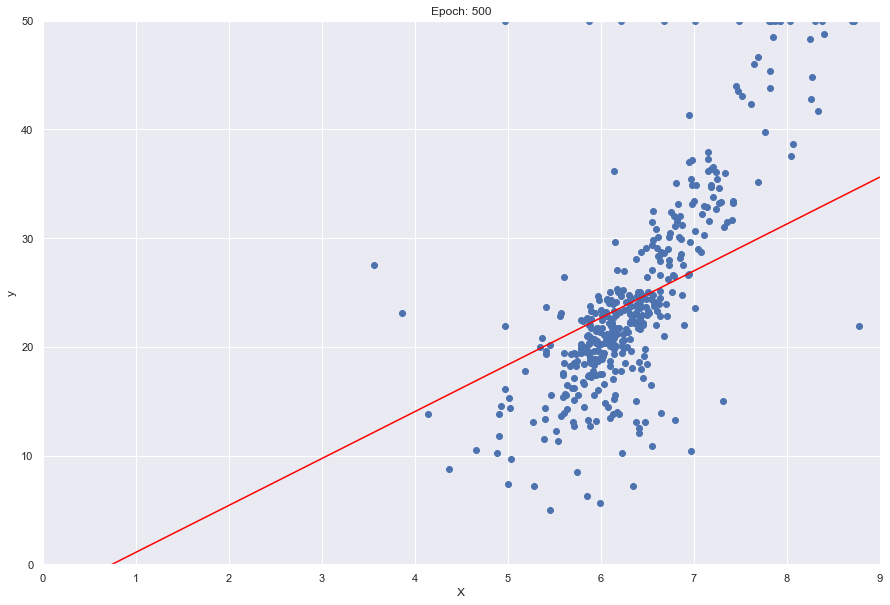

epoch:  1000 average loss:  48.5484175753501


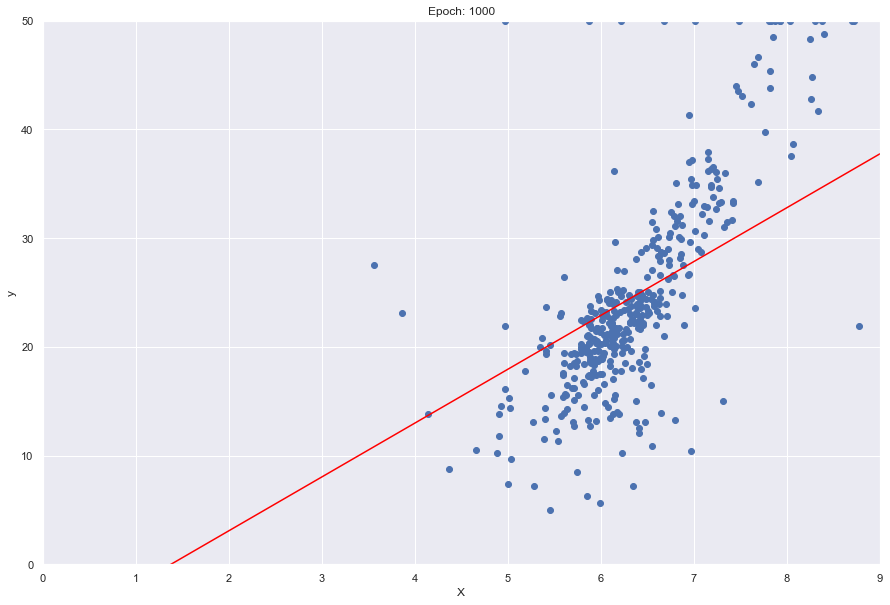

epoch:  1500 average loss:  48.83972650540647


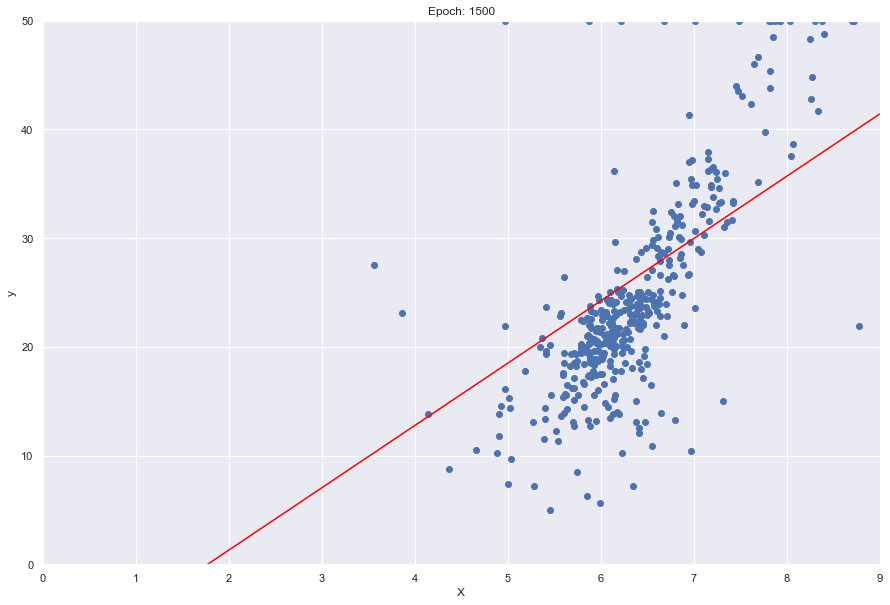

epoch:  2000 average loss:  44.33195815943223


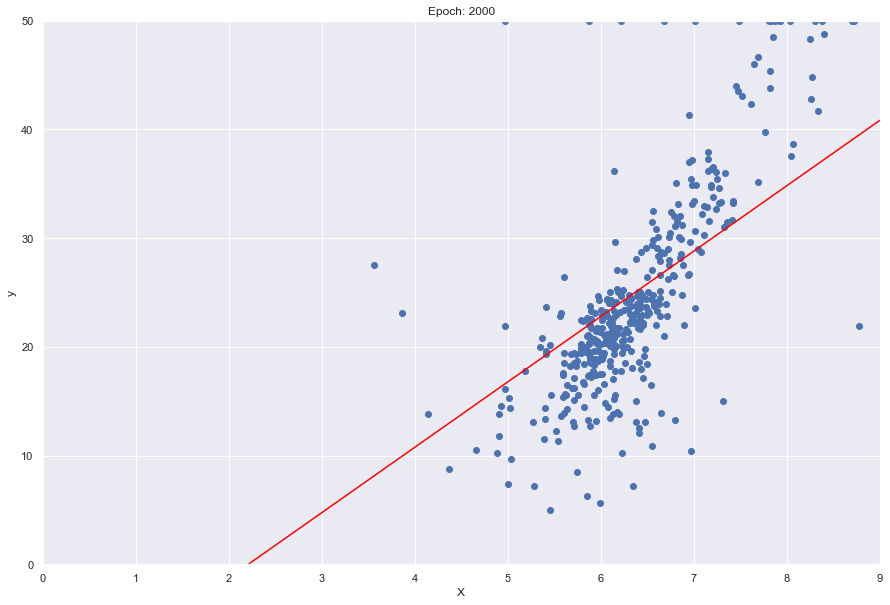

epoch:  2500 average loss:  45.22953821744628


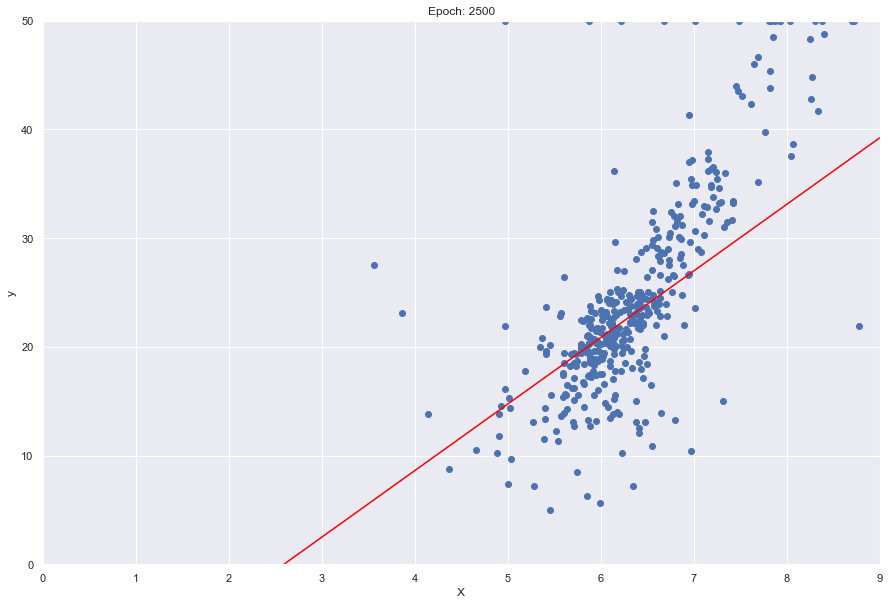

epoch:  3000 average loss:  42.22945875140979


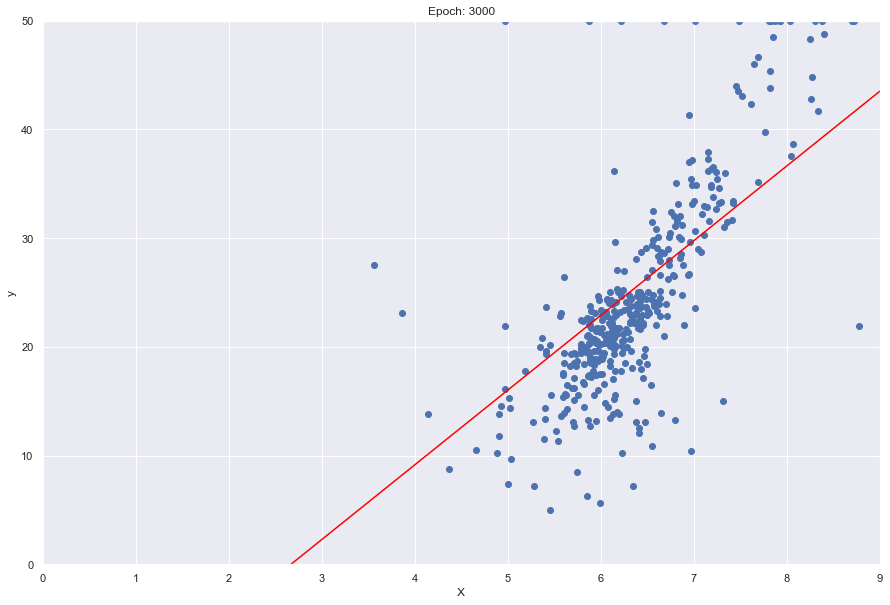

epoch:  3500 average loss:  41.538790746770204


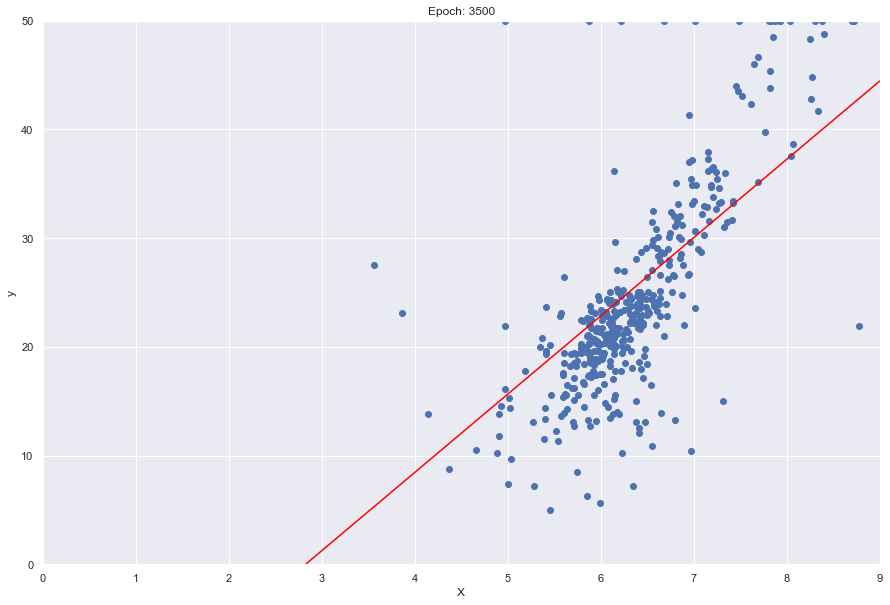

epoch:  4000 average loss:  41.040870064849976


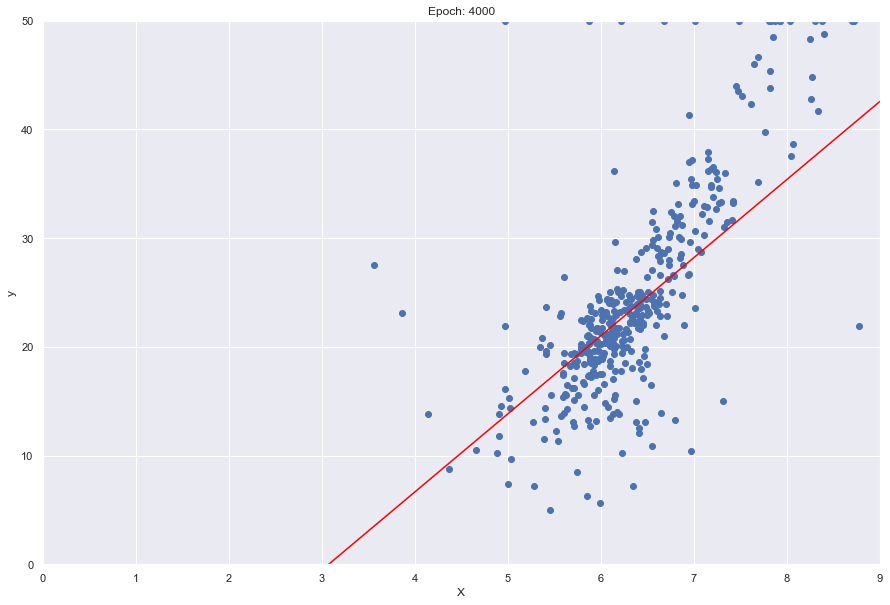

epoch:  4500 average loss:  39.957954274139865


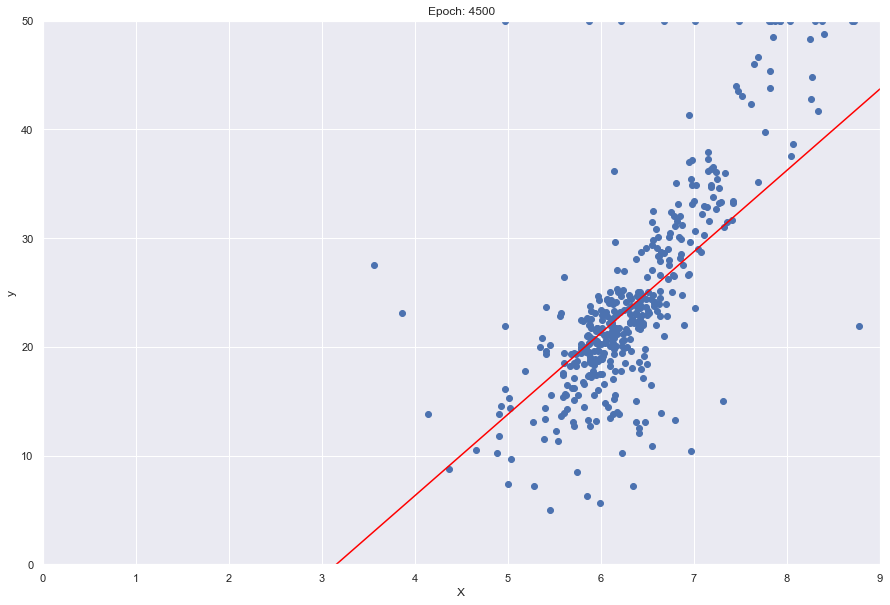

epoch:  5000 average loss:  39.238387908359556


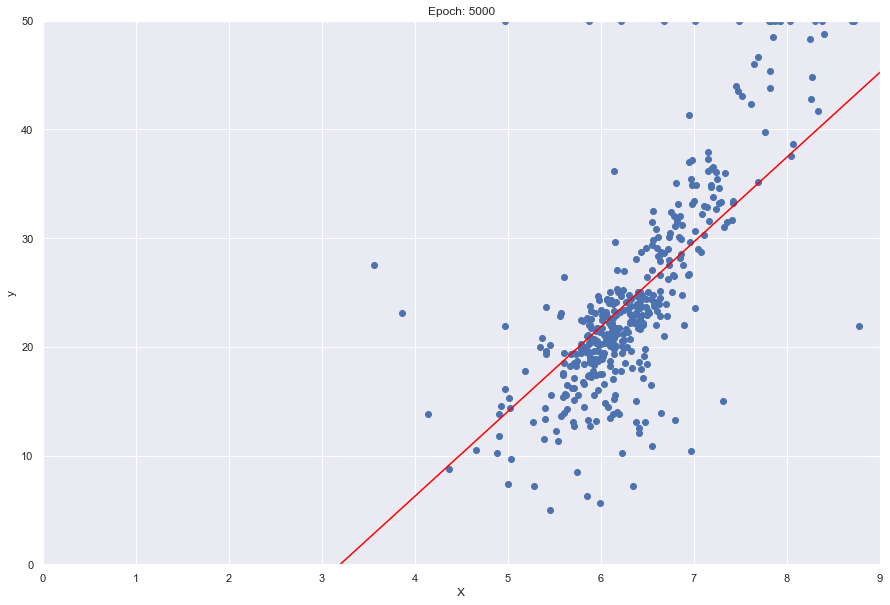

epoch:  5500 average loss:  39.30682225462885


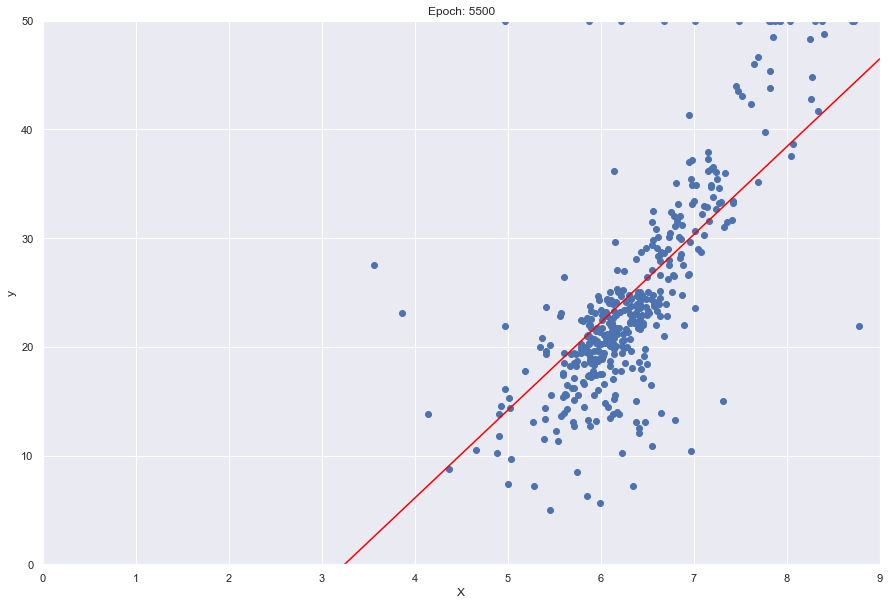

epoch:  6000 average loss:  39.689257196279556


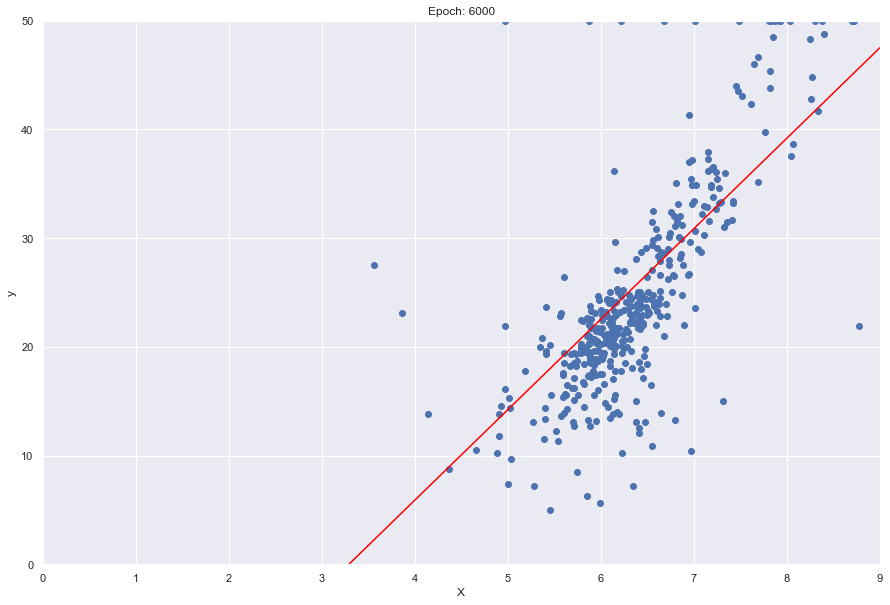

epoch:  6500 average loss:  39.05804715903805


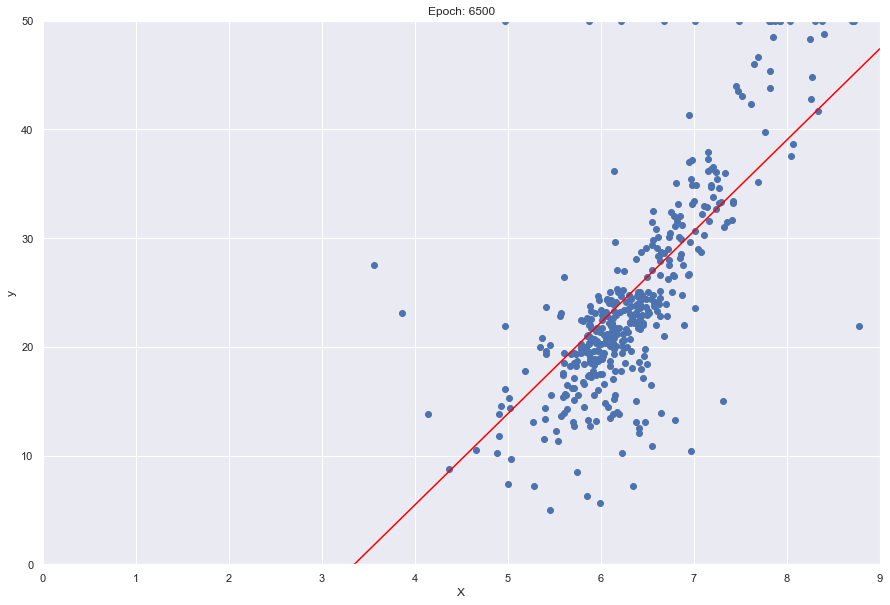

epoch:  7000 average loss:  38.46773229048245


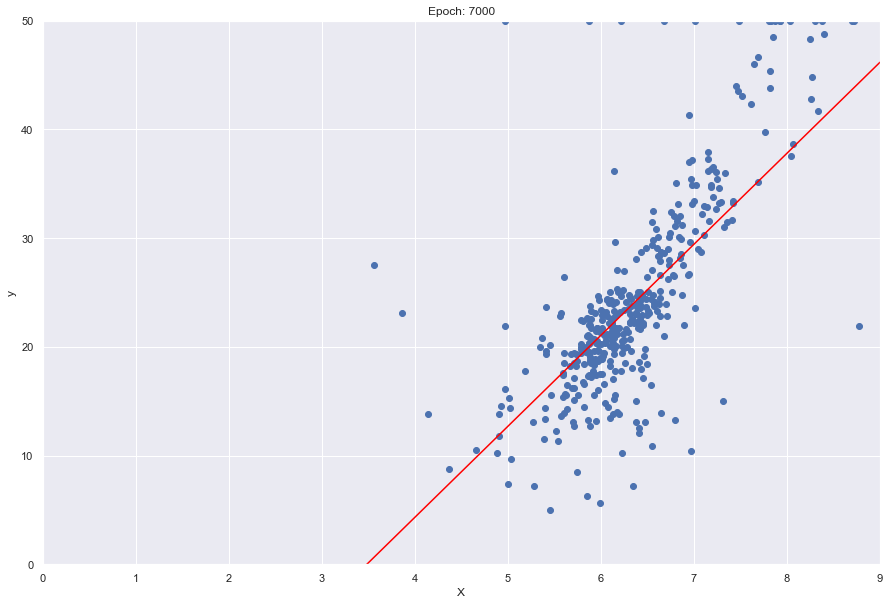

epoch:  7500 average loss:  38.64898704648203


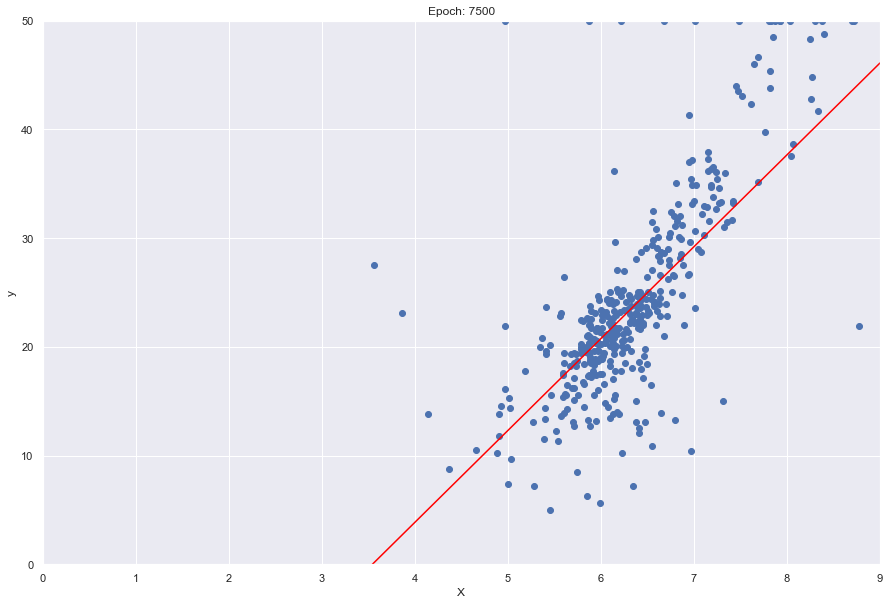

epoch:  8000 average loss:  38.63575121731515


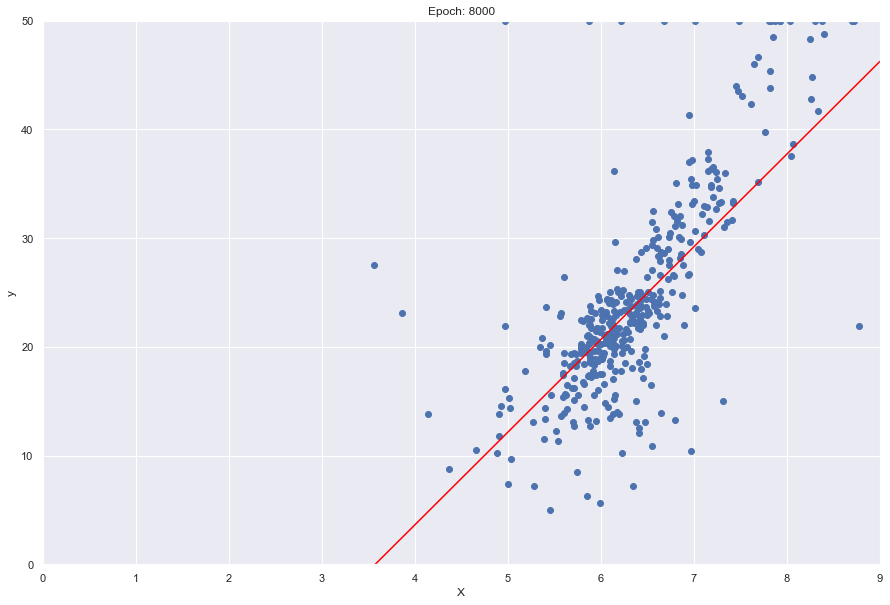

epoch:  8500 average loss:  40.093527455992835


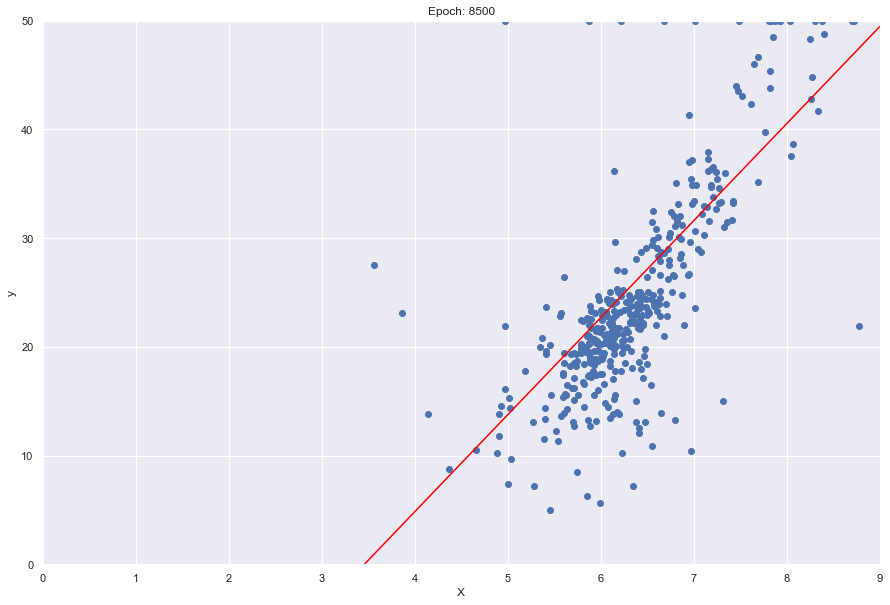

epoch:  9000 average loss:  37.98207564293301


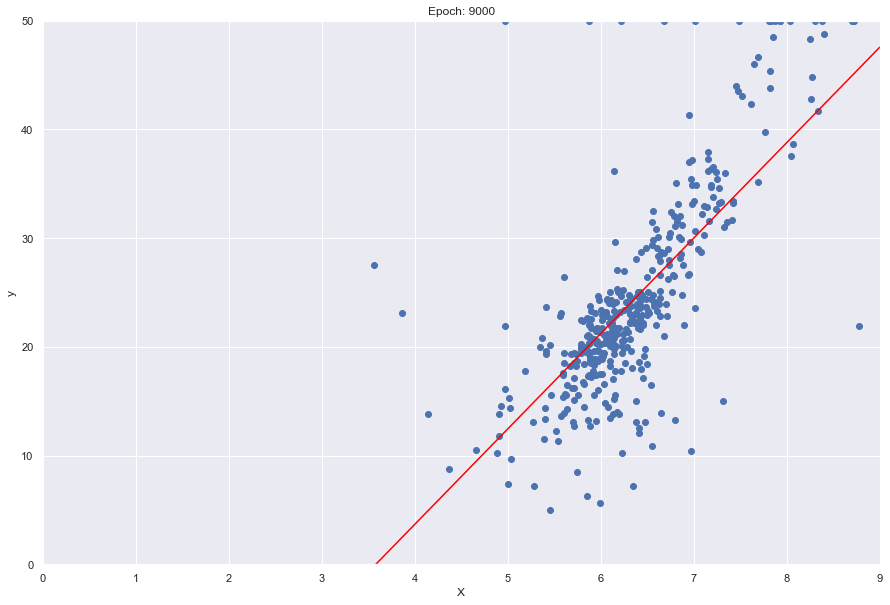

epoch:  9500 average loss:  39.51304273286074


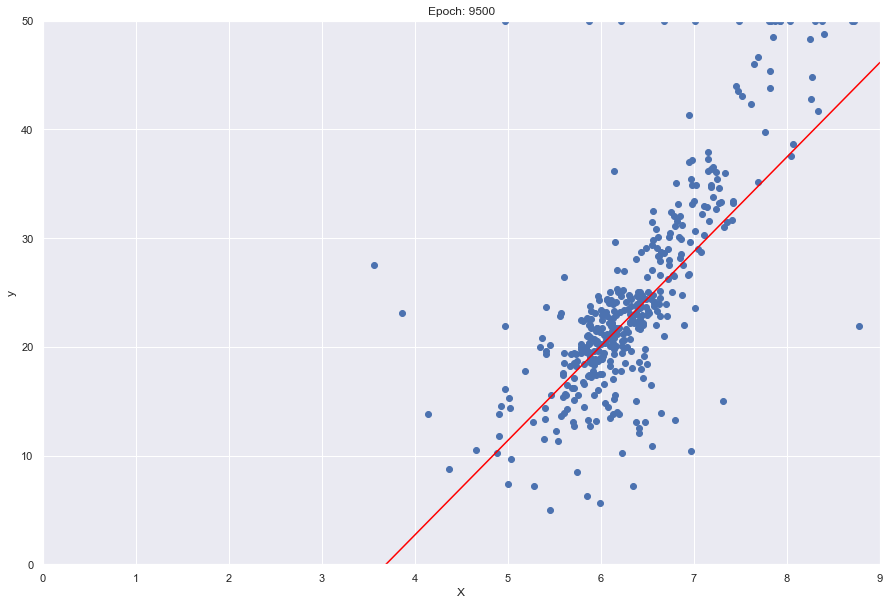

In [73]:
w_list,b_list, avg_loss_list, w, b, img_list, pred_val_at_diff_epoch = train(df["RM"][0:403], df["MEDV"][0:403], 0, 0, 0.001, 10000)

In [74]:
print(len(w_list))
print(len(b_list))
print(len(avg_loss_list))
print("best value for w: ",w)
print("best value for b: ",b)
print(len(img_list))
print(len(pred_val_at_diff_epoch))

1000
1000
1000
best value for w:  8.831031490188177
best value for b:  -32.49315721225533
20
20


In [75]:
n = np.linspace(10, 10000, 1000, endpoint = True)
len(n)

1000

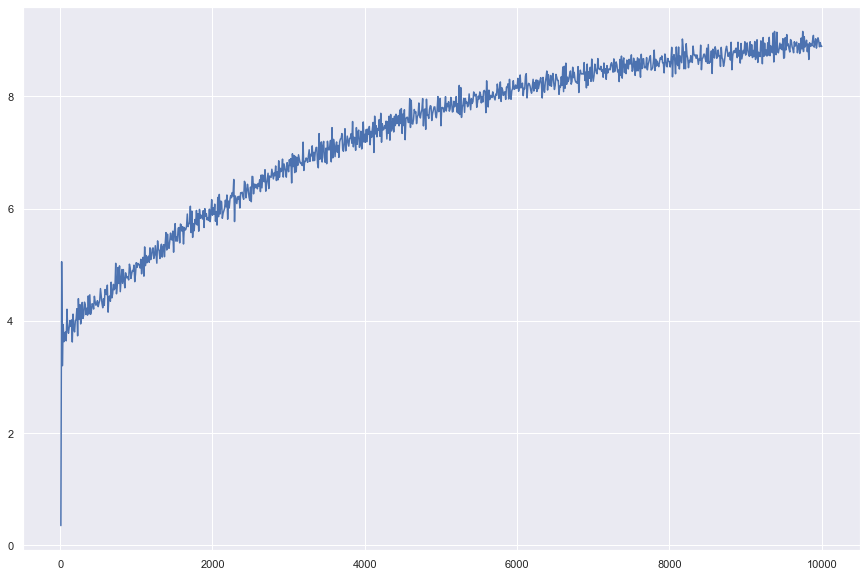

In [76]:
sns.set(rc = {"figure.figsize" : (15, 10)})
plt.plot(n, w_list)
plt.show()

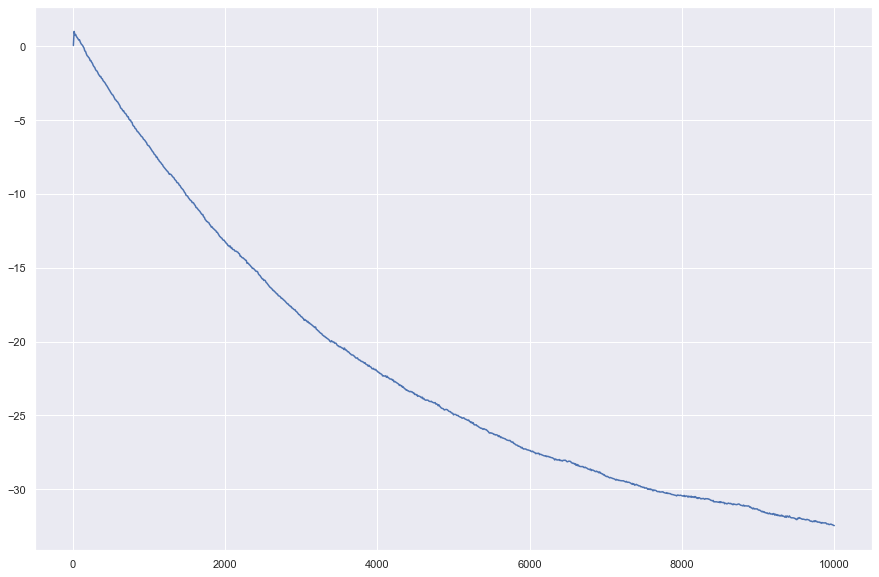

In [77]:
plt.plot(n, b_list)
plt.show()

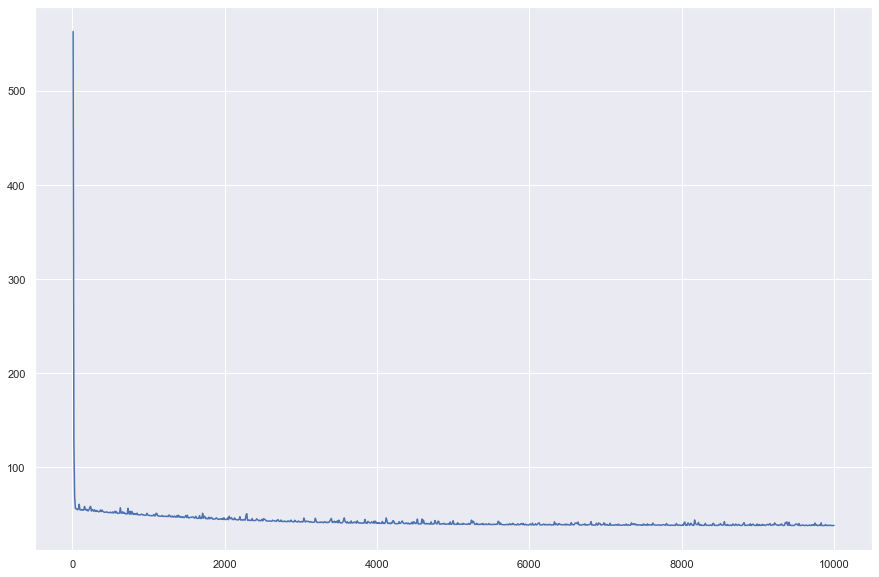

In [78]:
plt.plot(n, avg_loss_list)
plt.show()

In [79]:
predicted_vals = []
for feature in df["RM"]:
    predicted_vals.append(predict(feature, w, b))

In [80]:
predictedY_vs_realY = pd.DataFrame()

In [81]:
predictedY_vs_realY["REAL Y"] = df["MEDV"]
predictedY_vs_realY["PREDICTED Y"] = predicted_vals
predictedY_vs_realY["ERROR"] = abs(predictedY_vs_realY["REAL Y"] - predictedY_vs_realY["PREDICTED Y"])

In [82]:
predictedY_vs_realY.head()

,REAL Y,PREDICTED Y,ERROR
0,24.0,25.570875,1.570875
1,21.6,24.210896,2.610896
2,34.7,30.957804,3.742196
3,33.4,29.306401,4.093599
4,36.2,30.622225,5.577775


In [86]:
import imageio
with imageio.get_writer('gradient_descent_01.gif', mode='I') as writer:
    for filename in img_list:
        image = imageio.imread(filename)
        writer.append_data(image)